In [1]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print("SIA Wevengers 분석 환경 준비 완료")

SIA Wevengers 분석 환경 준비 완료


In [2]:
# 1. 고위험군 CAMEO 코드 리스트
target_cameo_codes = [ 
    '150', '151', '152', '153', '154', '155', 
    '190', '191', '192', '193', '194', '195', '196', 
    '200', '201', '202', '203', '204'
]
formatted_codes = ", ".join([f"'{code}'" for code in target_cameo_codes])

query = f"""
SELECT 
    SQLDATE, 
    IsRootEvent,
    EventCode, 
    GoldsteinScale, 
    NumMentions,
    AvgTone,
    ActionGeo_Type,
    ActionGeo_Lat, 
    ActionGeo_Long, 
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE SQLDATE >= 20130401
  AND IsRootEvent = 1
  AND ActionGeo_Type IN (3, 4, 5)
  AND (
    (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR 
    (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
  )
  AND EventCode IN ({formatted_codes})
"""

project_id = "project-fe69a478-943f-4a4a-bc6" # 로그인창 연결됨
df = pandas_gbq.read_gbq(query, project_id=project_id)

# 결과 확인
print(f"2013년부터 2026년 현재까지 총 {len(df)}건의 데이터를 불러왔습니다.(필터링 적용 O)")
display(df.head())

Downloading: 100%|██████████|
2013년부터 2026년 현재까지 총 11897건의 데이터를 불러왔습니다.(필터링 적용 O)


,SQLDATE,IsRootEvent,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20160703,1,194,-10.0,10,-2.929427,4,39.9289,116.388,http://focus-fen.net/opinion/2016/07/02/4417/h...
1,20160703,1,194,-10.0,2,-3.960396,4,28.4005,116.900,http://www.chinapost.com.tw/commentary/china-p...
2,20160813,1,193,-10.0,5,-3.529412,4,25.0327,121.275,http://focustaiwan.tw/news/acs/201608130012.aspx
3,20160813,1,193,-10.0,4,-5.263158,4,26.8941,117.865,http://focustaiwan.tw/news/asoc/201608130006.aspx
4,20160813,1,192,-9.5,1,1.034126,4,32.9447,111.031,http://www.sydneysun.com/index.php/nav/mreview...


In [3]:
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d')

print(df.shape)

(11897, 10)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11897 entries, 0 to 11896
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   SQLDATE         11897 non-null  datetime64[ns]
 1   IsRootEvent     11897 non-null  Int64         
 2   EventCode       11897 non-null  object        
 3   GoldsteinScale  11897 non-null  float64       
 4   NumMentions     11897 non-null  Int64         
 5   AvgTone         11897 non-null  float64       
 6   ActionGeo_Type  11897 non-null  Int64         
 7   ActionGeo_Lat   11897 non-null  float64       
 8   ActionGeo_Long  11897 non-null  float64       
 9   SOURCEURL       11897 non-null  object        
dtypes: Int64(3), datetime64[ns](1), float64(4), object(2)
memory usage: 964.4+ KB


In [5]:
df.isna().sum() # 결측치 없음.

SQLDATE           0
IsRootEvent       0
EventCode         0
GoldsteinScale    0
NumMentions       0
AvgTone           0
ActionGeo_Type    0
ActionGeo_Lat     0
ActionGeo_Long    0
SOURCEURL         0
dtype: int64

In [6]:
df.describe()

,SQLDATE,IsRootEvent,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long
count,11897,11897.0,11897.000000,11897.0,11897.000000,11897.0,11897.000000,11897.000000
mean,2021-07-11 19:00:32.983104768,1.0,-8.817996,13.300412,-2.505625,3.993864,30.852349,109.916208
min,2013-04-01 00:00:00,1.0,-10.000000,1.0,-18.181818,3.0,-41.300000,-157.972000
25%,2019-09-05 00:00:00,1.0,-10.000000,2.0,-3.900584,4.0,24.650300,116.388000
50%,2022-06-11 00:00:00,1.0,-10.000000,5.0,-2.523659,4.0,25.047800,118.318000
75%,2023-08-03 00:00:00,1.0,-7.200000,10.0,-1.150748,4.0,39.928900,121.532000
max,2026-05-04 00:00:00,1.0,-7.200000,1468.0,10.550459,5.0,67.939700,178.417000
std,NaN,0.0,1.344023,51.402282,2.355780,0.248153,9.124798,39.478505


## 1. 기사량(NumMentions) 기반 EDA

- 증가율 분포
- 기간별 기사량 분포 -> 최소 기사량? 선정?

In [45]:
## 날짜 기준 총 기사량으로 저장..
daily_counts = (
    df.groupby('SQLDATE')['NumMentions']
    .sum()
    .reset_index()
    .sort_values('SQLDATE')
)

# 비어있는 날짜 데이터 채우기
## 실제 14일 이동평균이 아니라  최근 14개 관측치 평균을 내게 되기에 이 부분 추가하기
daily_counts = daily_counts.set_index('SQLDATE').asfreq('D', fill_value=0)
daily_counts = daily_counts.reset_index()

daily_counts.head()

,SQLDATE,NumMentions
0,2013-04-01,8
1,2013-04-02,0
2,2013-04-03,0
3,2013-04-04,0
4,2013-04-05,0


In [46]:
## 7 / 14 / 30 기준 이동평균선 생성
for window in [7, 14, 30]:
    daily_counts[f'ma_{window}'] = (
        daily_counts['NumMentions']
        .rolling(window=window, min_periods=1)
        .mean()
    )

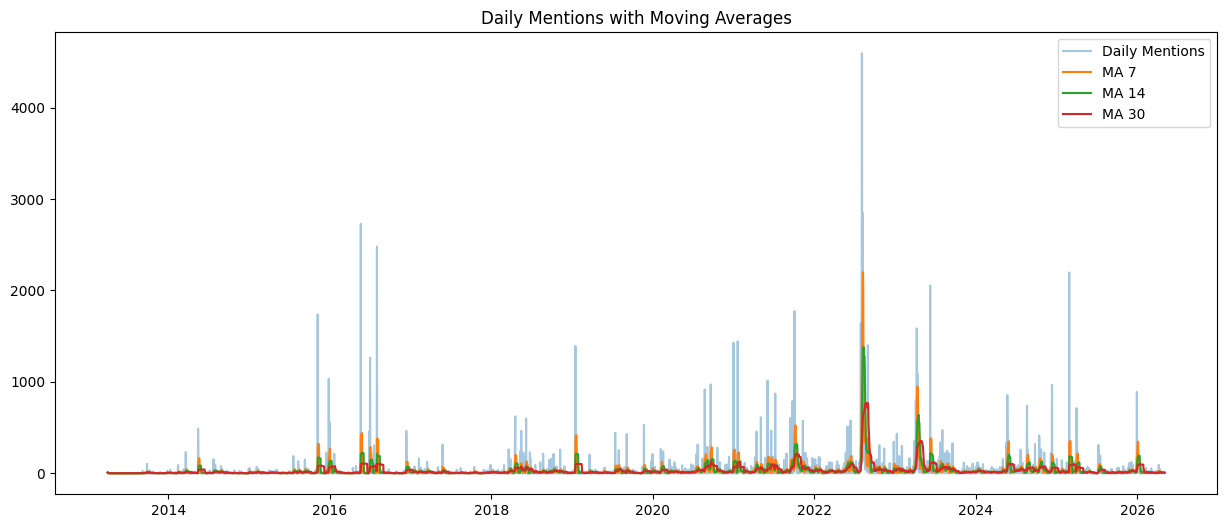

In [47]:
plt.figure(figsize=(15,6))

plt.plot(daily_counts['SQLDATE'], daily_counts['NumMentions'], 
         label='Daily Mentions', alpha=0.4)

plt.plot(daily_counts['SQLDATE'], daily_counts['ma_7'], label='MA 7')
plt.plot(daily_counts['SQLDATE'], daily_counts['ma_14'], label='MA 14')
plt.plot(daily_counts['SQLDATE'], daily_counts['ma_30'], label='MA 30')

plt.legend()
plt.title('Daily Mentions with Moving Averages')
plt.show()

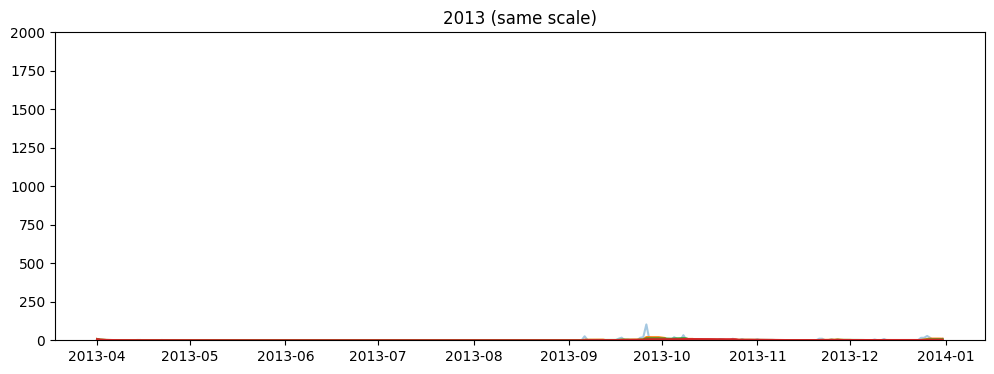

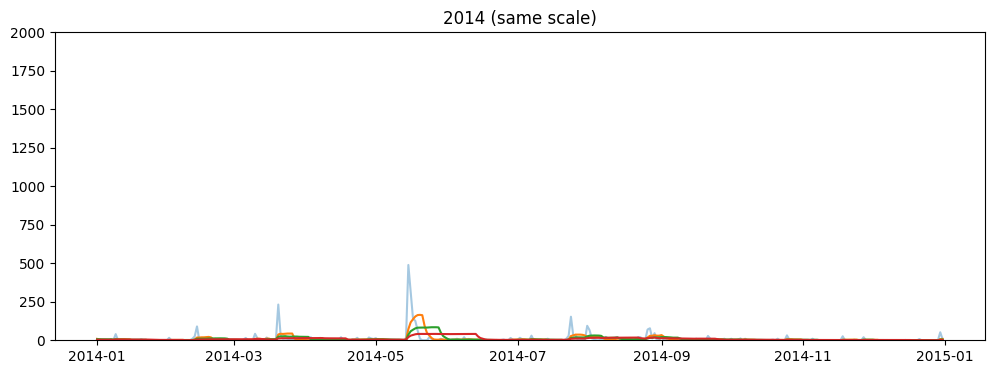

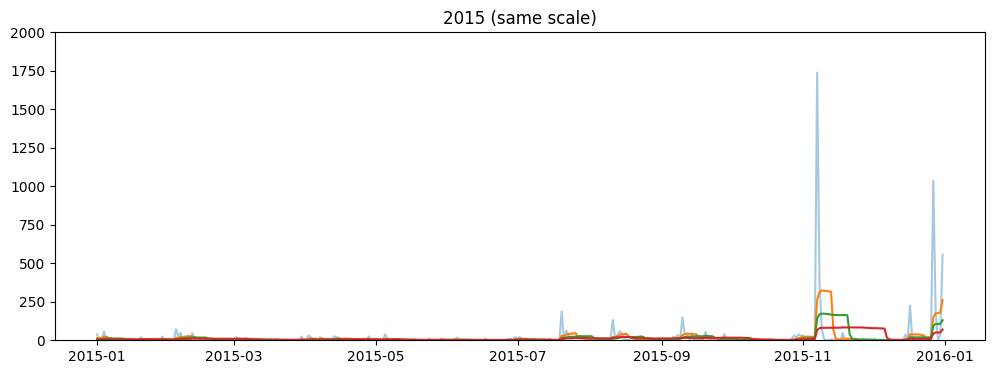

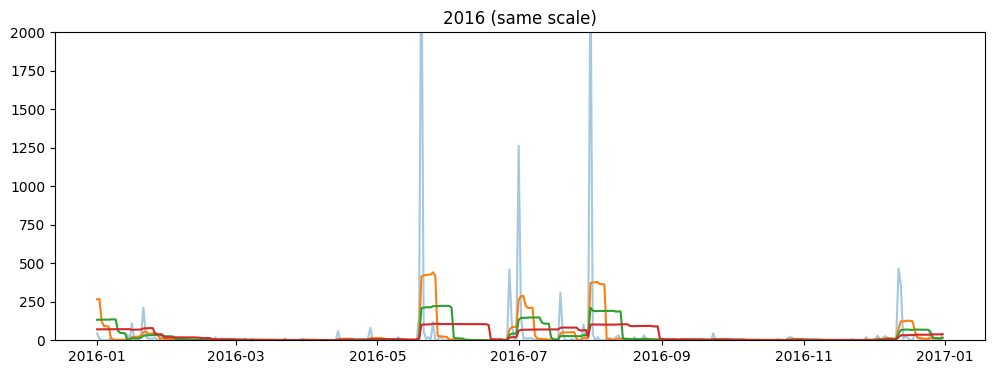

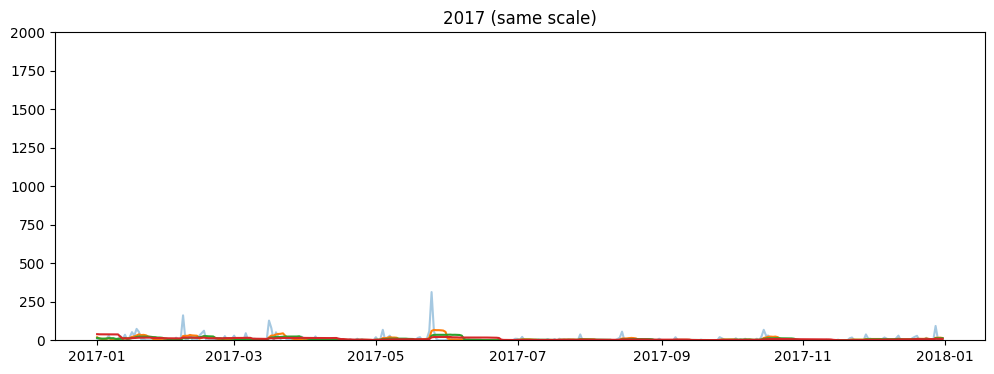

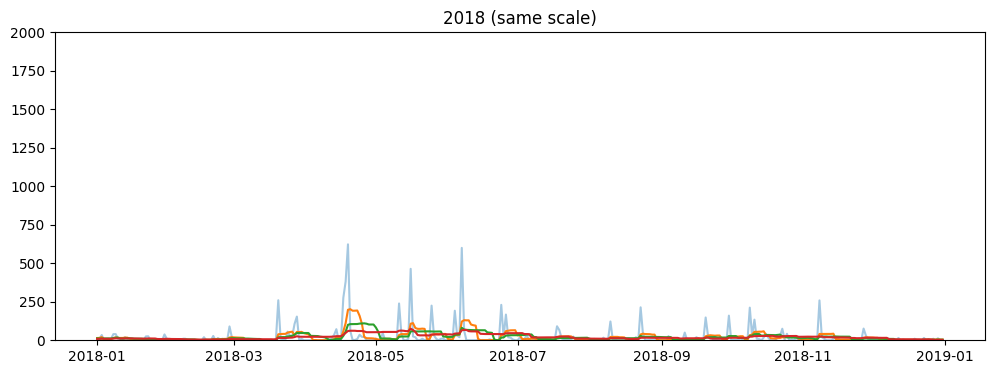

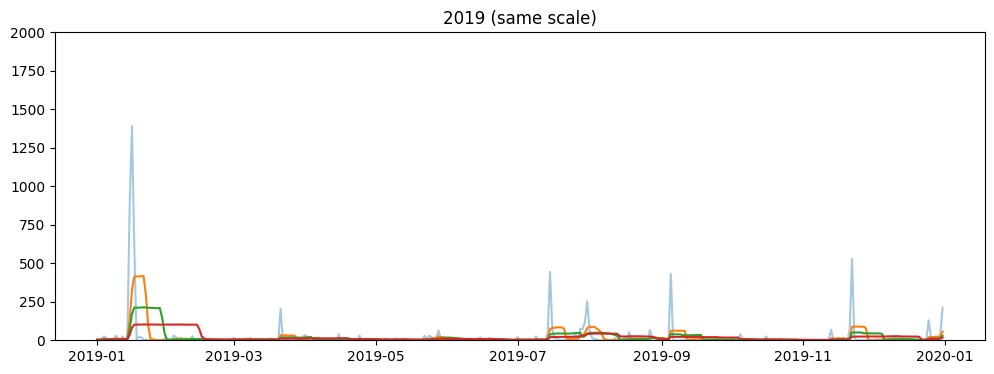

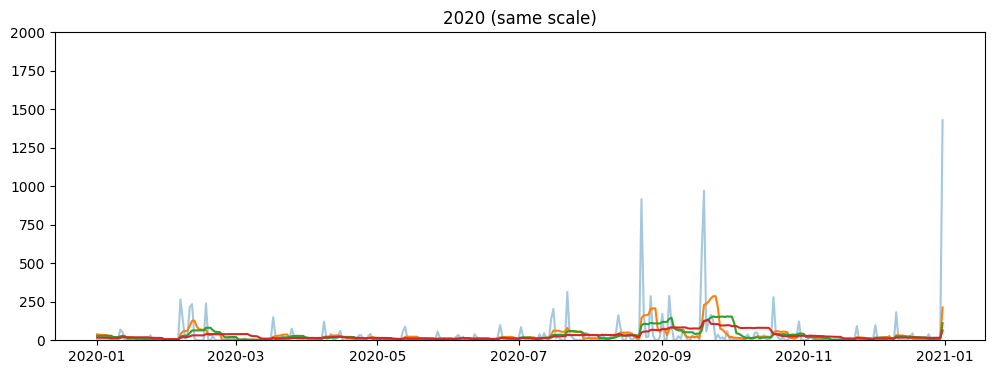

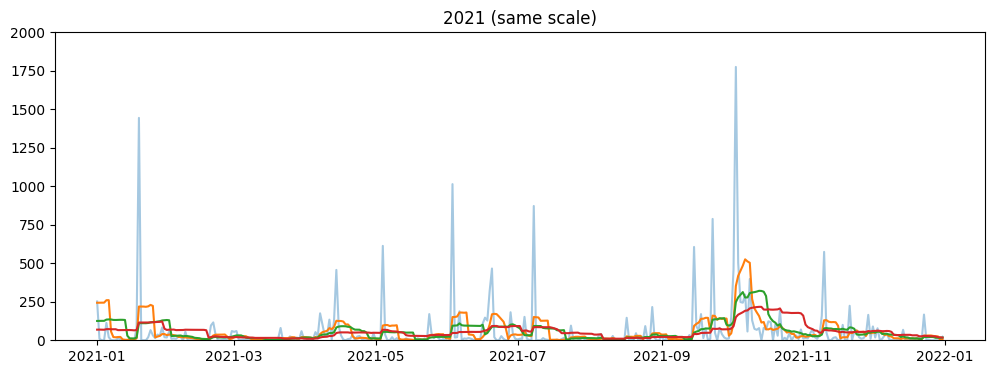

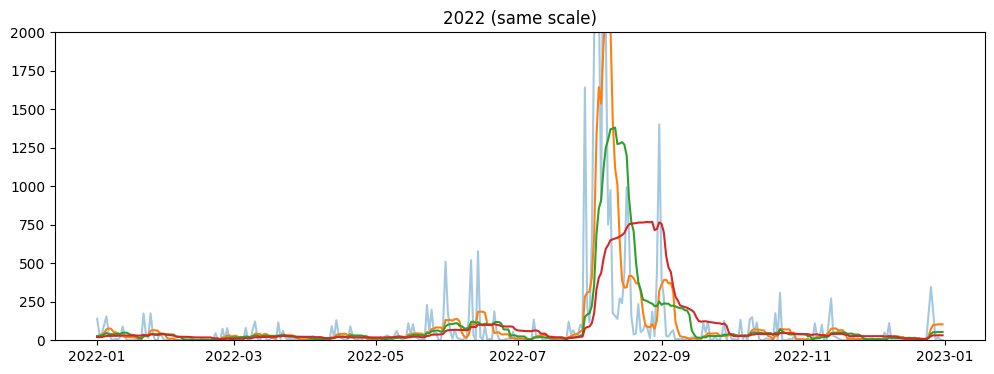

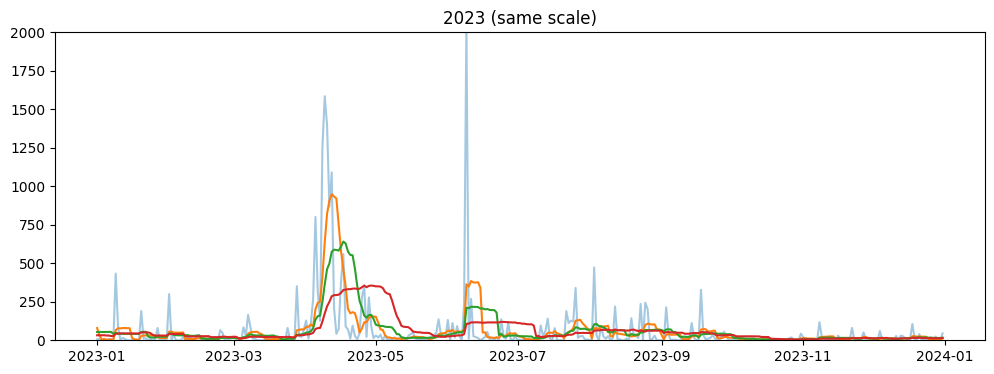

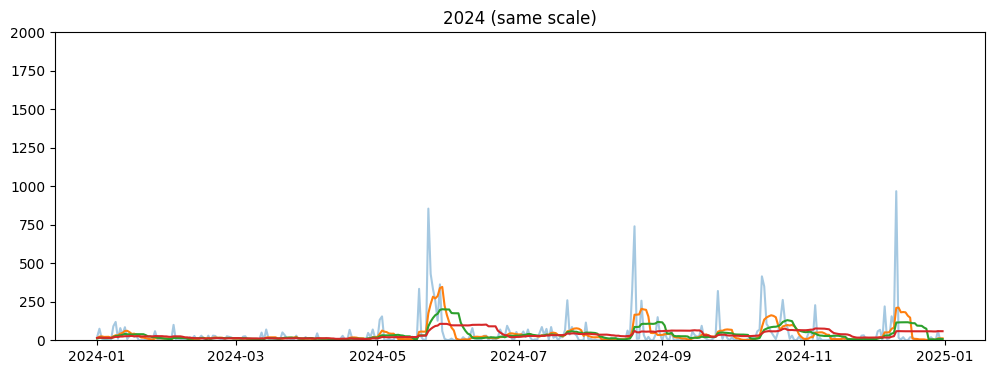

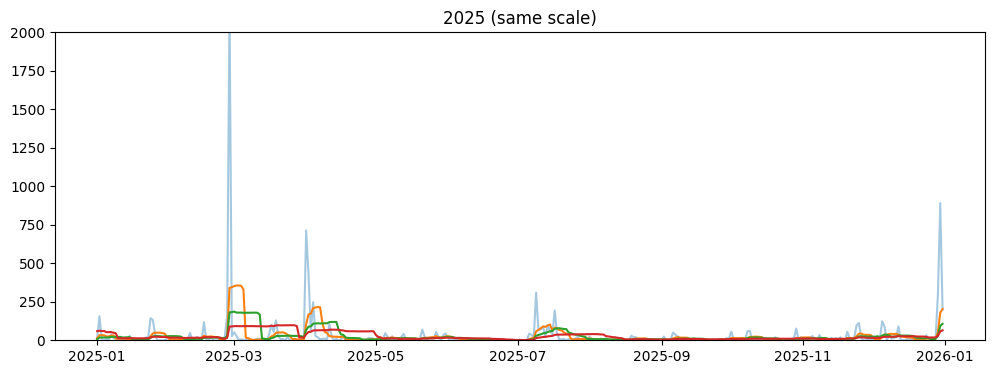

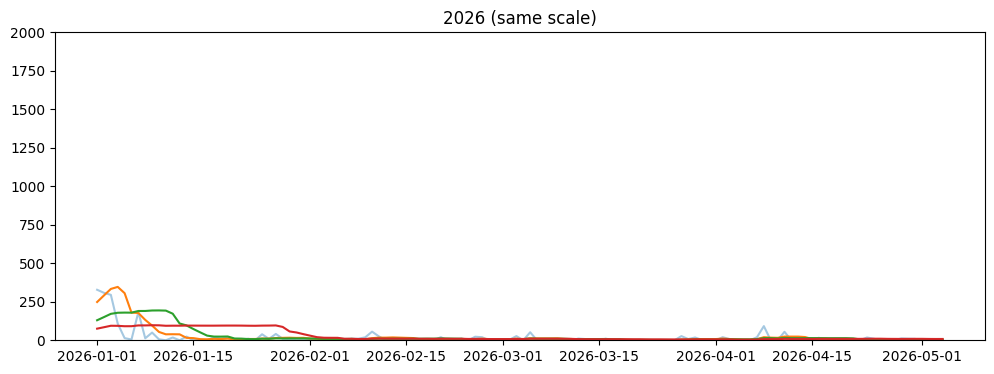

In [52]:
## 연도별로 쪼개서.. + y축 고정까지
daily_counts['year'] = daily_counts['SQLDATE'].dt.year
years = sorted(daily_counts['year'].unique())

y_max = 2000

for y in years:
    temp = daily_counts[daily_counts['year'] == y]
    
    plt.figure(figsize=(12,4))
    plt.plot(temp['SQLDATE'], temp['NumMentions'], alpha=0.4)
    plt.plot(temp['SQLDATE'], temp['ma_7'])
    plt.plot(temp['SQLDATE'], temp['ma_14'])
    plt.plot(temp['SQLDATE'], temp['ma_30'])
    
    plt.ylim(0, y_max)
    plt.title(f'{y} (same scale)')
    plt.show()

#### 결과 해석
- MA 7: 너무 민감 (nosie 많음)

- MA 14: spike 잡음, noise 상대적 제거됨. -> 이벤트 지속 기간과 맞음 (대략 1~2주 간격)

- MA 30: spike 이후에도 계속 높게 유지됨 -> 반응이 너무 느린듯 -> 이벤트 탐지 시점 늦어질 가능성 UP.

In [62]:
## 증가율 계산
"""
for window in [7, 14, 30]:
    daily_counts[f'growth_{window}'] = (
        (daily_counts['NumMentions'] - daily_counts[f'ma_{window}']) 
        / daily_counts[f'ma_{window}']
    )
"""

import numpy as np

for window in [7,14,30]:

    ma_col = f'ma_{window}'
    growth_col = f'growth_{window}'

    daily_counts[growth_col] = np.where(
        daily_counts[ma_col] > 0,
        (daily_counts['NumMentions'] - daily_counts[ma_col]) / daily_counts[ma_col],
        np.nan
    )

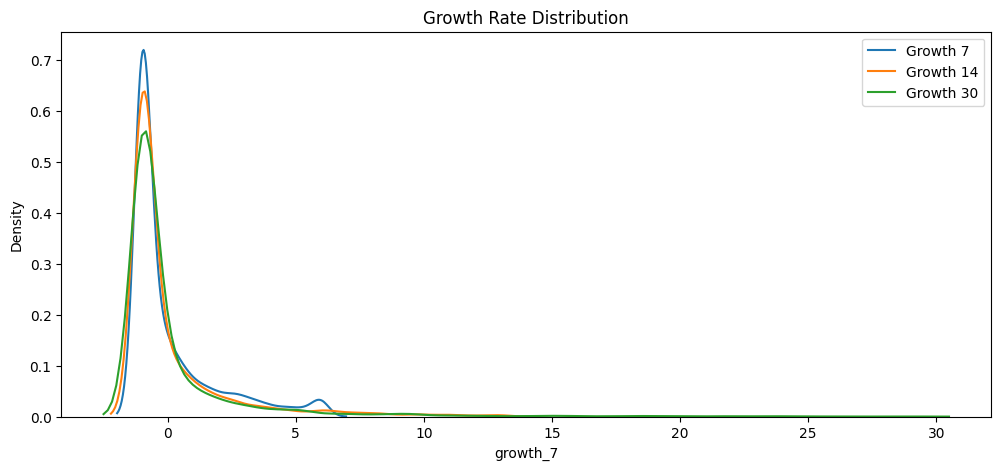

In [63]:
plt.figure(figsize=(12,5))

for window in [7, 14, 30]:
    sns.kdeplot(daily_counts[f'growth_{window}'], label=f'Growth {window}')

plt.legend()
plt.title('Growth Rate Distribution')
plt.show()

In [64]:
for window in [7,14,30]:
    print(f"{window}일 기준")
    print(daily_counts[f'growth_{window}'].describe())
    print()

7일 기준
count    4413.000000
mean        0.062812
std         1.727157
min        -1.000000
25%        -1.000000
50%        -0.855546
75%         0.400000
max         6.000000
Name: growth_7, dtype: float64

14일 기준
count    4631.000000
mean        0.086736
std         2.178755
min        -1.000000
25%        -1.000000
50%        -0.933722
75%         0.087383
max        13.000000
Name: growth_14, dtype: float64

30일 기준
count    4675.000000
mean        0.092126
std         2.703654
min        -1.000000
25%        -1.000000
50%        -0.949163
75%        -0.110668
max        29.000000
Name: growth_30, dtype: float64



In [65]:
for window in [7,14,30]:
    print(f"{window}일 95%:", daily_counts[f'growth_{window}'].quantile(0.95))

7일 95%: 4.257865168539318
14일 95%: 4.833333333333334
30일 95%: 4.6631680128990265


In [66]:
## 기사량 절대값 기준 분석
daily_counts['NumMentions'].describe()

count        4782.0
mean      33.089711
std      158.265431
min             0.0
25%             0.0
50%             1.0
75%            15.0
max          4595.0
Name: NumMentions, dtype: Float64

In [67]:
daily_counts['NumMentions'].quantile([0.9, 0.95, 0.99])

0.90      55.0
0.95     127.0
0.99    562.66
Name: NumMentions, dtype: Float64

- 상위 구간 비교: 100 이상부터는 이미 '비정상적으로 많은 기사'임을 의미함.

### 1-2. 같은 사건에 대한 기사량 분포

### 1-3. 실제 spike 검증
- Q. 실제로 이상 이벤트가 잘 잡히는가?
- 결과 확인 후, 기준 조정.

In [68]:
## 일별 총 기사량 집계
df_counts = (
    df.groupby('SQLDATE')['NumMentions']
      .sum()
      .reset_index()
      .sort_values('SQLDATE')
)

# 비어있는 날짜 데이터 채우기
## 실제 14일 이동평균이 아니라  최근 14개 관측치 평균을 내게 되기에 이 부분 추가하기
df_counts = df_counts.set_index('SQLDATE').asfreq('D', fill_value=0)
df_counts = df_counts.reset_index()

df_counts.head(20)

,SQLDATE,NumMentions
0,2013-04-01,8
1,2013-04-02,0
2,2013-04-03,0
3,2013-04-04,0
4,2013-04-05,0
5,2013-04-06,0
6,2013-04-07,0
7,2013-04-08,0
8,2013-04-09,0
9,2013-04-10,0


In [70]:
# 14일 이동평균
df_counts['ma_14'] = (
    df_counts['NumMentions']
    .rolling(window=14, min_periods=7)
    .mean()
)

# 증가율 계산
df_counts['growth_14'] = np.where(
        df_counts['ma_14'] > 0,
        (df_counts['NumMentions'] - df_counts['ma_14']) / df_counts['ma_14'],
        np.nan
)

In [76]:
# 임시 threshold
growth_threshold = 5
mention_threshold = 125

spike_days = df_counts[
    (df_counts['growth_14'] > growth_threshold) &
    (df_counts['NumMentions'] > mention_threshold)
].copy()

spike_days = spike_days.sort_values('NumMentions', ascending=False)

print(f"탐지된 spike 날짜 수: {len(spike_days)}")
display(spike_days)

탐지된 spike 날짜 수: 85


,SQLDATE,NumMentions,ma_14,growth_14
3412,2022-08-04,4595,692.000000,5.640173
1145,2016-05-20,2729,208.642857,12.079767
1218,2016-08-01,2480,211.571429,10.721810
4350,2025-02-27,2197,181.357143,11.114218
3721,2023-06-09,2055,210.785714,8.749238
...,...,...,...,...
4316,2025-01-24,143,16.714286,7.555556
3385,2022-07-08,134,16.357143,7.192140
862,2015-08-11,132,10.071429,12.106383
2459,2019-12-25,130,10.357143,11.551724


In [89]:
# 임시 threshold
growth_threshold = 5
mention_threshold = 500

spike_days = df_counts[
    (df_counts['growth_14'] > growth_threshold) &
    (df_counts['NumMentions'] > mention_threshold)
].copy()

spike_days = spike_days.sort_values('NumMentions', ascending=False)

print(f"탐지된 spike 날짜 수: {len(spike_days)}")
display(spike_days)

탐지된 spike 날짜 수: 30


,SQLDATE,NumMentions,ma_14,growth_14
3412,2022-08-04,4595,692.000000,5.640173
1145,2016-05-20,2729,208.642857,12.079767
1218,2016-08-01,2480,211.571429,10.721810
4350,2025-02-27,2197,181.357143,11.114218
3721,2023-06-09,2055,210.785714,8.749238
3107,2021-10-03,1775,247.785714,6.163448
950,2015-11-07,1738,141.142857,11.313765
3407,2022-07-30,1642,152.000000,9.802632
2850,2021-01-19,1444,112.428571,11.843710
2831,2020-12-31,1429,110.714286,11.907097


In [77]:
### Spike 날짜에 해당하는 원본 이벤트 확인

# spike 날짜 목록
spike_dates = spike_days['SQLDATE'].tolist()

# 원본 df에서 spike 날짜에 해당하는 이벤트만 추출
spike_events = df[df['SQLDATE'].isin(spike_dates)].copy()

print(f"Spike 날짜에 해당하는 원본 이벤트 수: {len(spike_events)}")
display(spike_events.head())

Spike 날짜에 해당하는 원본 이벤트 수: 1473


,SQLDATE,IsRootEvent,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
25,2016-06-27,1,150,-7.2,4,0.653595,4,25.0478,121.532,http://thevillagessuntimes.com/2016/06/27/taiw...
26,2016-06-27,1,150,-7.2,12,-1.097517,4,39.9289,116.388,http://www.business-standard.com/article/pti-s...
27,2016-06-27,1,194,-10.0,240,-1.370145,4,39.9289,116.388,http://www.themalaymailonline.com/world/articl...
28,2016-06-27,1,150,-7.2,138,-1.162233,4,39.9289,116.388,http://www.themalaymailonline.com/world/articl...
29,2016-06-27,1,150,-7.2,5,-1.237113,4,25.0478,121.532,http://www.manilatimes.net/breaking_news/taiwa...


In [82]:
from IPython.display import display, HTML

# URL을 클릭 가능한 HTML 링크로 바꾸는 함수
def make_clickable(url):
    return f'<a href="{url}" target="_blank">{url}</a>'

In [85]:
### 날짜별 주요 이벤트 요약 보기

spike_summary = (
    spike_events
    .groupby(['SQLDATE', 'EventCode'])
    .agg(
        event_count=('EventCode', 'count'),
        total_mentions=('NumMentions', 'sum'),
        avg_goldstein=('GoldsteinScale', 'mean'),
        avg_tone=('AvgTone', 'mean'),
        sample_url=('SOURCEURL', 'first')
    )
    .reset_index()
    .sort_values(['total_mentions', 'SQLDATE'], ascending=[False, True])
)

# 클릭 가능한 URL로 변환
spike_summary_html = spike_summary.copy()
spike_summary_html['sample_url'] = spike_summary_html['sample_url'].apply(make_clickable)

display(HTML(spike_summary_html.to_html(escape=False, index=False)))

SQLDATE,EventCode,event_count,total_mentions,avg_goldstein,avg_tone,sample_url
2022-08-04,194,52,2859,-10.0,-3.154531,https://americanmilitarynews.com/2022/08/china-fires-11-ballistic-missiles-toward-taiwan-japan/
2016-08-01,190,12,2480,-10.0,-1.787786,http://www.dailymail.co.uk/wires/ap/article-3717643/Taiwan-president-apologizes-aboriginals-suffering.html
2023-06-09,190,13,2014,-10.0,1.214830,https://www.msn.com/en-us/news/world/chinese-naval-ship-heads-for-philippines-in-friendly-tour/ar-AA1cjZiL
2015-11-07,192,5,1701,-9.5,-1.486399,http://www.WLOX.com/story/30460867/a-china-taiwan-handshake-66-years-in-the-making
2021-10-03,192,12,1598,-9.5,-4.276938,https://www.koreatimes.co.kr/www/world/2021/10/683_316381.html
2022-07-30,150,15,1576,-7.2,-2.919343,https://www.wionews.com/world/top-10-world-news-chinese-military-drills-in-taiwan-strait-bilawal-bhutto-speaks-to-wion-and-more-502095
2016-05-20,150,2,1530,-7.2,1.066792,https://espresso.economist.com/3b9d6e5e779c8f46c5765c194a04b59a
2021-01-19,190,2,1436,-10.0,-1.718055,https://infotel.ca/newsitem/as-taiwan-china-military/cp1546221171
2020-12-31,151,4,1390,-7.2,-3.148529,https://www.sfgate.com/news/article/China-accuses-US-of-show-of-force-with-Taiwan-15837534.php
2022-08-04,150,57,1380,-7.2,-2.936503,https://apnews.com/article/taiwan-technology-health-asia-china-4e66d6d2944204a5261b4bfbe0048688


- 2022-08-04 : 펠로시 대만 방문 직후 중국 대규모 군사훈련 시기. (+ 탄도 미사일 발사)
- 2021-10-03 : 중국 군용기 대만 ADIZ 진입 관련 시기
- 2020-12-31 : 미중 갈등, 대만 긴장..

In [86]:
### 날짜별 상위 URL 확인

for d in spike_days['SQLDATE'].head(10):
    print("=" * 80)
    print(f"Spike Date: {d.date()}")
    
    temp = spike_events[spike_events['SQLDATE'] == d].copy()
    temp = temp.sort_values('NumMentions', ascending=False)

    show_cols = [
        'SQLDATE',
        'EventCode',
        'GoldsteinScale',
        'AvgTone',
        'NumMentions',
        'ActionGeo_Type',
        'ActionGeo_Lat',
        'ActionGeo_Long',
        'SOURCEURL'
    ]

    temp_html = temp[show_cols].head(10).copy()
    temp_html['SOURCEURL'] = temp_html['SOURCEURL'].apply(make_clickable)

    display(HTML(temp_html.to_html(escape=False, index=False)))

Spike Date: 2022-08-04


SQLDATE,EventCode,GoldsteinScale,AvgTone,NumMentions,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
2022-08-04,194,-10.0,-4.222615,700,4,28.7925,117.2620,https://wflapanamacity.iheart.com/content/2022-08-04-china-launches-missile-as-it-begins-live-fire-military-drills-around-taiwan/
2022-08-04,194,-10.0,-4.772964,536,4,24.0000,119.0000,https://www.wkms.org/npr-news/npr-news/2022-08-04/china-fires-waves-of-missiles-over-the-taiwan-strait-raising-tensions-in-the-region
2022-08-04,150,-7.2,-2.070194,378,4,39.9289,116.3880,https://www.stuff.co.nz/world/asia/300654066/china-tightens-noose-with-taiwan-blockade
2022-08-04,194,-10.0,-4.222615,300,4,32.9500,116.6420,https://wflapanamacity.iheart.com/content/2022-08-04-china-launches-missile-as-it-begins-live-fire-military-drills-around-taiwan/
2022-08-04,194,-10.0,-3.074827,281,4,25.0478,121.5320,https://www.bbc.com/news/live/world-asia-62404233
2022-08-04,194,-10.0,-3.880930,265,4,39.9289,116.3880,https://inlandnewstoday.com/story.php?s=68209
2022-08-04,194,-10.0,-3.681634,159,4,39.9289,116.3880,https://www.investmentwatchblog.com/china-has-established-a-blockade-around-taiwan-and-plans-to-shoot-missiles-directly-over-the-island/
2022-08-04,150,-7.2,-2.139968,130,4,39.9289,116.3880,https://inlandnewstoday.com/story.php?s=68209
2022-08-04,194,-10.0,-2.073469,101,3,38.8951,-77.0364,https://www.bignewsnetwork.com/news/272642549/china-fires-hypersonic-missiles-in-taiwan-blockade-drill---media
2022-08-04,150,-7.2,-2.530253,96,4,24.1098,113.0050,https://www.msn.com/en-us/news/world/facing-growing-threats-from-china-these-big-war-games-are-how-taiwan-prepares-to-fend-off-a-chinese-invasion/ar-AA10igSj


Spike Date: 2016-05-20


SQLDATE,EventCode,GoldsteinScale,AvgTone,NumMentions,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
2016-05-20,150,-7.2,1.060794,1468,4,39.9289,116.388,http://news.findlaw.com/apnews/ed3c65a9a0204c1f8219736d78af0133
2016-05-20,190,-10.0,1.027422,288,4,39.9289,116.388,http://news.findlaw.com/apnews/ed3c65a9a0204c1f8219736d78af0133
2016-05-20,190,-10.0,1.027422,288,4,39.9289,116.388,http://news.findlaw.com/apnews/ed3c65a9a0204c1f8219736d78af0133
2016-05-20,190,-10.0,-3.208292,239,4,39.9289,116.388,http://macaudailytimes.com.mo/taiwan-leader-faces-thornier-ties-china-growth-woes.html
2016-05-20,190,-10.0,1.027422,192,4,39.9289,116.388,http://news.findlaw.com/apnews/ed3c65a9a0204c1f8219736d78af0133
2016-05-20,190,-10.0,1.027422,192,4,39.9289,116.388,http://news.findlaw.com/apnews/ed3c65a9a0204c1f8219736d78af0133
2016-05-20,150,-7.2,1.072790,62,4,39.9289,116.388,https://espresso.economist.com/3b9d6e5e779c8f46c5765c194a04b59a


Spike Date: 2016-08-01


...

SQLDATE,EventCode,GoldsteinScale,AvgTone,NumMentions,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
2022-07-30,150,-7.2,-2.146788,1465,4,39.9289,116.388,https://www.sfgate.com/news/article/China-announces-military-exercise-opposite-Taiwan-17339911.php
2022-07-30,190,-10.0,-2.255639,60,4,39.9289,116.388,https://www.bignewsnetwork.com/news/272637930/china-conducts-military-exercises-amid-tensions-with-us
2022-07-30,150,-7.2,-2.255639,36,4,25.0327,121.275,https://www.bignewsnetwork.com/news/272637930/china-conducts-military-exercises-amid-tensions-with-us
2022-07-30,150,-7.2,-2.600889,22,4,39.9289,116.388,https://infotel.ca/newsitem/as-china-taiwan/cp1289139445
2022-07-30,150,-7.2,-2.719872,8,4,39.9289,116.388,https://www.mymotherlode.com/news/asia/2694326/china-announces-military-exercise-opposite-taiwan.html
2022-07-30,150,-7.2,-3.609626,6,4,32.8925,13.180,https://www.wionews.com/world/top-10-world-news-chinese-military-drills-in-taiwan-strait-bilawal-bhutto-speaks-to-wion-and-more-502095
2022-07-30,150,-7.2,-3.614458,6,4,24.7570,121.753,https://article.wn.com/view/2022/07/30/China_announces_military_exercise_opposite_Taiwan_p0/
2022-07-30,193,-10.0,-3.780069,6,4,39.9289,116.388,https://ground.news/article/white-house-refuses-to-address-threat-to-shoot-down-pelosi-from-chinese-state-media-member
2022-07-30,150,-7.2,-3.688525,6,4,24.1098,113.005,https://www.msn.com/en-in/news/world/ahead-of-pelosi-s-visit-to-taiwan-china-to-begin-military-drills-in-taiwan-strait/ar-AA107vO9
2022-07-30,150,-7.2,-0.170940,4,4,25.0478,121.532,https://news.ltn.com.tw/news/focus/breakingnews/4009368


Spike Date: 2021-01-19


SQLDATE,EventCode,GoldsteinScale,AvgTone,NumMentions,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
2021-01-19,190,-10.0,-1.271789,1406,4,24.0000,119.00000,https://www.9news.com.au/world/taiwan-stages-military-defence-drill-against-potential-china-attack/2dbe3bab-0ba6-4509-b03b-78b419a4523c
2021-01-19,190,-10.0,-2.164320,30,4,24.0000,119.00000,https://infotel.ca/newsitem/as-taiwan-china-military/cp1546221171
2021-01-19,154,-7.2,5.681818,8,4,46.1956,6.14811,https://www.haitilibre.com/en/news-32810-haiti-diplomacy-new-ambassador-of-haiti-to-taiwan.html


Spike Date: 2020-12-31


SQLDATE,EventCode,GoldsteinScale,AvgTone,NumMentions,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
2020-12-31,151,-7.2,-3.208156,1190,4,24.0000,119.0000,https://www.sfgate.com/news/article/China-accuses-US-of-show-of-force-with-Taiwan-15837534.php
2020-12-31,151,-7.2,-3.279477,194,4,24.0000,119.0000,https://www.decaturdaily.com/news/other_news/national/china-accuses-us-of-show-of-force-with-taiwan-strait-passage/article_2a9de986-2b8b-511c-b272-f118c25e7eb3.html
2020-12-31,152,-7.2,-1.918203,30,4,25.0478,121.5320,https://www.aninews.in/news/world/asia/taiwan-tightens-noose-on-chinese-investments-over-security-concerns20201231123602/
2020-12-31,192,-9.5,-5.594406,5,4,39.9289,116.3880,https://www.theepochtimes.com/china-in-focus-dec-30-ccp-virus-cases-surge-medical-staff-silenced_3638656.html
2020-12-31,151,-7.2,-2.631579,4,4,24.0000,119.0000,https://www.thetelegraph.com/news/article/China-accuses-US-of-show-of-force-with-Taiwan-15837534.php
2020-12-31,150,-7.2,-0.699301,2,4,10.7500,106.6670,https://www.stripes.com/news/pacific/us-navy-ends-2020-with-another-taiwan-strait-transit-1.656979
2020-12-31,150,-7.2,-0.699301,2,4,10.7500,106.6670,https://www.stripes.com/news/pacific/us-navy-ends-2020-with-another-taiwan-strait-transit-1.656979
2020-12-31,151,-7.2,-3.474903,2,3,38.8951,-77.0364,https://economictimes.indiatimes.com/news/defence/china-accuses-united-states-of-show-of-force-with-taiwan-strait-passage/articleshow/80044711.cms


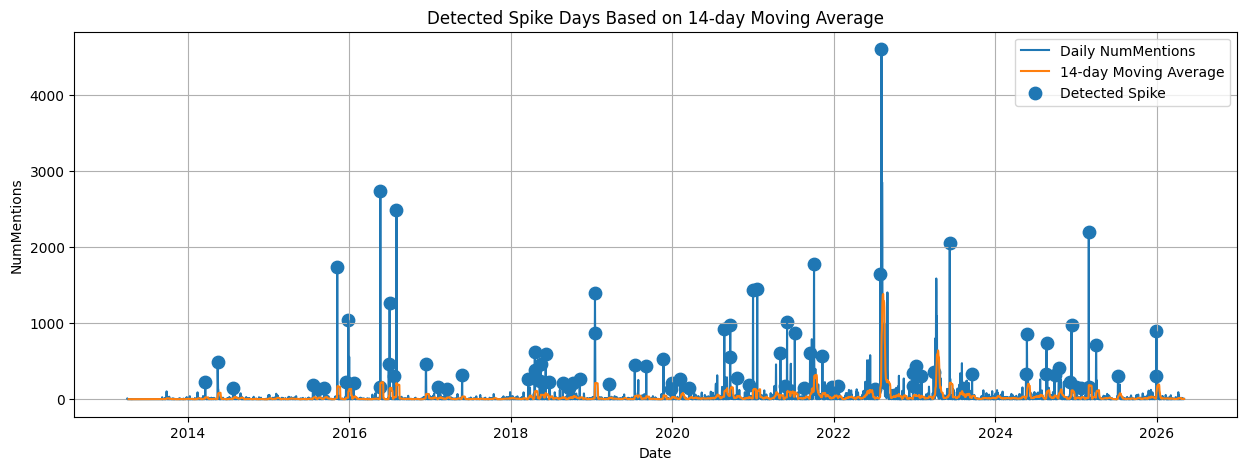

In [87]:
plt.figure(figsize=(15, 5))

plt.plot(df_counts['SQLDATE'], df_counts['NumMentions'], label='Daily NumMentions')
plt.plot(df_counts['SQLDATE'], df_counts['ma_14'], label='14-day Moving Average')

plt.scatter(
    spike_days['SQLDATE'],
    spike_days['NumMentions'],
    label='Detected Spike',
    s=80
)

plt.title('Detected Spike Days Based on 14-day Moving Average')
plt.xlabel('Date')
plt.ylabel('NumMentions')
plt.legend()
plt.grid(True)
plt.show()

In [88]:
## 이벤트 코드 별 분석

spike_summary.groupby('EventCode').agg({
    'total_mentions': ['count', 'mean', 'max'],
    'avg_goldstein': 'mean',
    'avg_tone': 'mean'
}).sort_values(('total_mentions', 'count'), ascending=False)

total_mentions                   avg_goldstein  avg_tone
                   count        mean   max          mean      mean
EventCode                                                         
190                   66   272.19697  2480         -10.0 -2.479005
150                   47  322.319149  1576          -7.2 -2.455324
192                   23  227.782609  1701          -9.5 -3.574501
154                   18   30.055556   230          -7.2 -2.008617
194                   14  491.214286  2859         -10.0 -2.765550
193                   13  271.384615  1285         -10.0 -2.545568
151                   13  185.153846  1390          -7.2 -2.562396
195                    9   78.888889   540         -10.0 -2.751389
152                    7   44.571429   170          -7.2 -2.434953
191                    2        55.0   105          -9.5 -1.738680
153                    1         4.0     4          -7.2  0.334672

- 194 code

- Event Code 별 가중치 주는 방법
    - 150번대 처럼 군사 훈련실시, 경계수준 강화 같은 조기탐지?가능성 범위의 코드는
    - 가중치를 낮게 주면 => 위성으로 식별 가능한 객체에 더 가중치 부여 가능할 듯.
    - 예) 기사량 대비 골드스테인 값이 큰 음수면 가중치 더 주기?

In [ ]:
# 군사적 요충지 리스트업 

## 2. GoldsteinScale (이벤트 강도)

In [90]:
## Spike VS Non-Spike 비교
# - 실제 spike 이벤트는 goldstein이 더 낮은가?
# - AvgTone이 더 부정적인가?

In [93]:
daily_counts['is_spike'] = (
    (daily_counts['growth_14'] > 4.8) &
    (daily_counts['NumMentions'] > 125)
)

In [94]:
# spike 날짜만 추출
spike_dates = daily_counts[daily_counts['is_spike']]['SQLDATE']

In [95]:
# 원본 이벤트에 spike 여부 부여
df['is_spike'] = df['SQLDATE'].isin(spike_dates)

In [97]:
# 비교
df.groupby('is_spike')[['GoldsteinScale', 'AvgTone']].describe()

GoldsteinScale                                                  \
                  count      mean       std   min   25%   50%  75%  max   
is_spike                                                                  
False           10305.0 -8.837370  1.338201 -10.0 -10.0 -10.0 -7.2 -7.2   
True             1592.0 -8.692588  1.374952 -10.0 -10.0  -9.5 -7.2 -7.2   

          AvgTone                                                     \
            count      mean       std        min       25%       50%   
is_spike                                                               
False     10305.0 -2.484312  2.398998 -18.181818 -3.911980 -2.513968   
True       1592.0 -2.643586  2.049477 -10.975610 -3.826531 -2.594006   

                               
               75%        max  
is_spike                       
False    -1.079137  10.550459  
True     -1.481367   5.729612

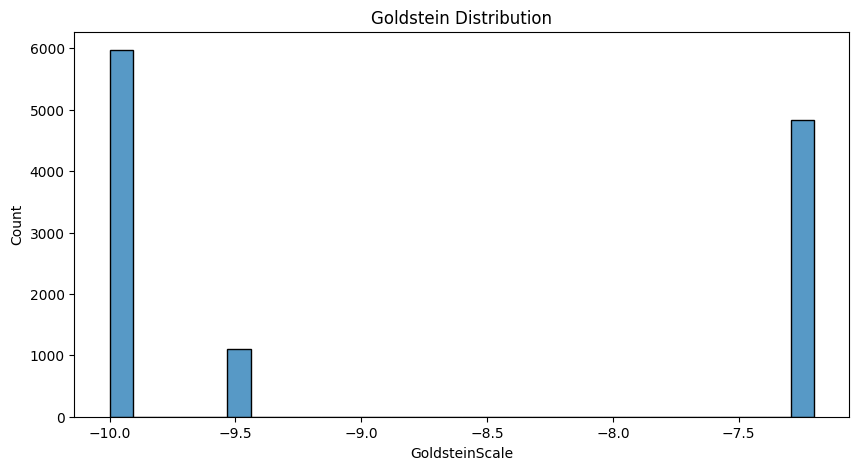

In [98]:
plt.figure(figsize=(10,5))

sns.histplot(df['GoldsteinScale'], bins=30)

plt.title('Goldstein Distribution')
plt.show()

In [99]:
## EventCode VS Goldstein 관계확인
# - Goldstein이 사실상 EventCode를 그대로 반영하는가?

In [100]:
df.groupby('EventCode')['GoldsteinScale'].value_counts()

EventCode  GoldsteinScale
150        -7.2              3068
151        -7.2               559
152        -7.2               124
153        -7.2                12
154        -7.2              1063
190        -10.0             3971
191        -9.5               136
192        -9.5               961
193        -10.0              671
194        -10.0              735
195        -10.0              538
201        -9.5                 2
202        -10.0               54
203        -10.0                3
Name: count, dtype: int64

## 3. AvgTone 분석 (뉴스 정서)

In [101]:
## AvgTone의 실제 유효성 확인

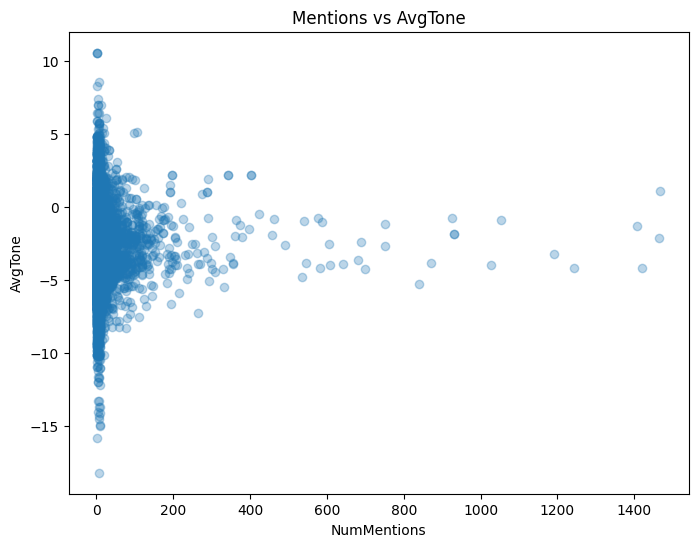

In [102]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['NumMentions'],
    df['AvgTone'],
    alpha=0.3
)

plt.xlabel('NumMentions')
plt.ylabel('AvgTone')
plt.title('Mentions vs AvgTone')

plt.show()

In [103]:
## Spike 이벤트들의 Tone만 따로 보기
# - 진짜 위험 이벤트는 tone이 더 부정적인가?

In [104]:
spike_events['AvgTone'].describe()

count    1473.000000
mean       -2.695759
std         2.039998
min       -10.975610
25%        -3.850851
50%        -2.637218
75%        -1.557377
max         5.729612
Name: AvgTone, dtype: float64

In [106]:
normal_events = df[df['is_spike']==False]
normal_events['AvgTone'].describe()

count    10305.000000
mean        -2.484312
std          2.398998
min        -18.181818
25%         -3.911980
50%         -2.513968
75%         -1.079137
max         10.550459
Name: AvgTone, dtype: float64

### 결과 해석 및 정리

- 해당 컬럼을 써야할지 말아야 할지보다는..
- 실제로 얼마나 유효한지 검증한 결과
    - tone, goldstein 영향력 감소
    - Spike / Non-Spike 비교 : 별 차이 없음 -> 변별력 약함 -> 굳이 사용해야 하나.?
    - 왜냐? -> 이미 군사적 긴장 이벤트로 필터링된 이벤트이기 때문....

- 그래서 오히려 지금 더 중요한건
- 어떤 군사 이베트인가? 가 더 중요한 것 같다.
    - 미사일 발사, 군대/함대 이동 등 
    - 의미적 군사 카테고리화가 중요할듯..
    - 이에 따른 rule-based 로직으로 우리가 직접 가중치를 매기던지,, -> event_weight
    - 아니면 골드스테인 가중치를 따로 설정해서 0.1 weight을 주면 좋을지..
        - 골드스테인스케일 은 카메오 코드별 점수 부여된 것이기 때문..
- 위성 관측 가능 이벤트 따로 정의하기
    - 군함, 항공기, 미사일, 군사훈련, 병력 이동 등....
- 또는 군사적 요충지 좌표에 가중치를 더 주던가... -> geo_weight
    - 그러면은, 요 위치에서는 중요한 사건, 반복적인 사건들이 많이 발생하니깐...
    - 지속성/반복성 패턴을 담을 수도 있지 않을까...?

LLM으로 좌표 비교 검증 -> 그 지역명/좌표를 가지고 확인을 해야 하지 않을까....

LLM API 필요함!!